# Simulations from Shaer et al. 

In [1]:
import numpy as np

def generate_dataset(n, beta=1.0, d=19, seed=None):
    rng = np.random.default_rng(seed)

    # Fixed parameters
    W = rng.normal(size=d)
    U = rng.normal(size=d)

    # Generate Z ~ N(0, I_d)
    Z = rng.normal(size=(n, d))

    # Generate X | Z ~ N(U^T Z, 1)
    X = Z @ U + rng.normal(size=n)

    # Generate Y
    epsilon = rng.normal(size=n)
    Y = (Z @ W) ** 2 + beta * X + epsilon

    # Design matrix: first column is X, remaining columns are Z
    X_design = np.column_stack((X, Z))

    return X_design, Y

In [2]:
import os

os.chdir("..")

In [3]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign


etas = prepare_exponential_parameters(0.01, 5, 10)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,

}

batch_list = [2, 5, 10]
j_vec = [i for i in np.arange(5)]
e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )


In [4]:
X, Y = generate_dataset(1000, beta=3.0, d=19, seed=None)


In [5]:
martingales = e_process.martingales(X, y=Y)

/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), 

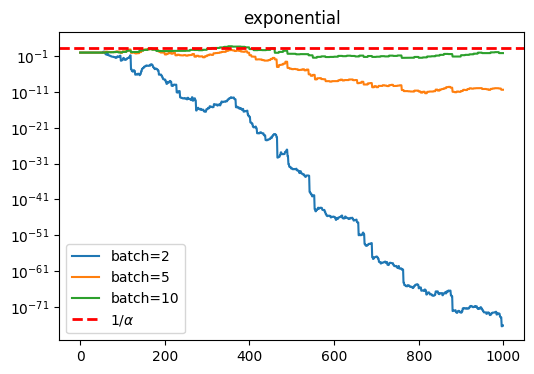

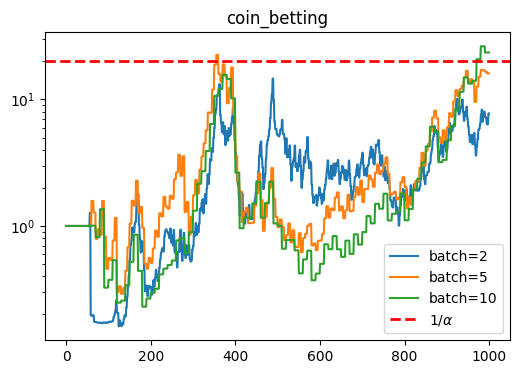

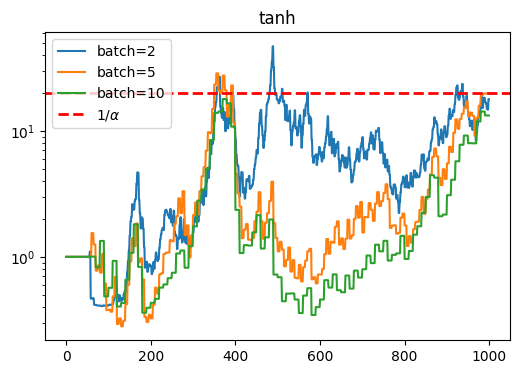

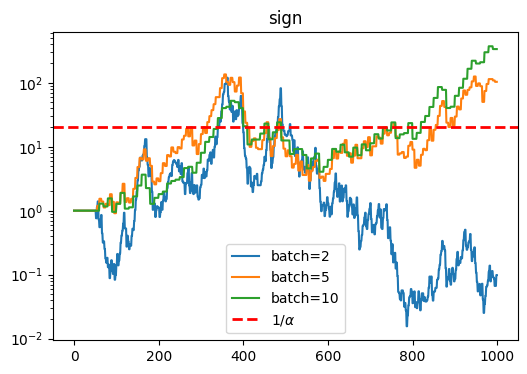

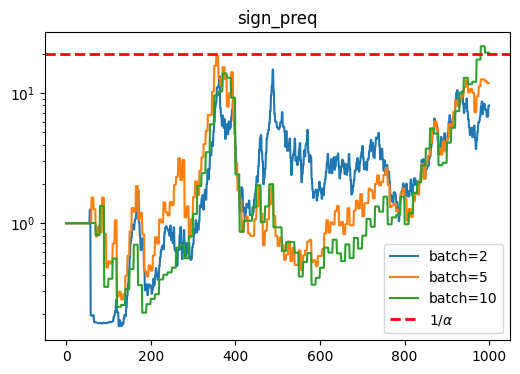

In [17]:
import matplotlib.pyplot as plt
alpha = 0.05
j = 0 
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

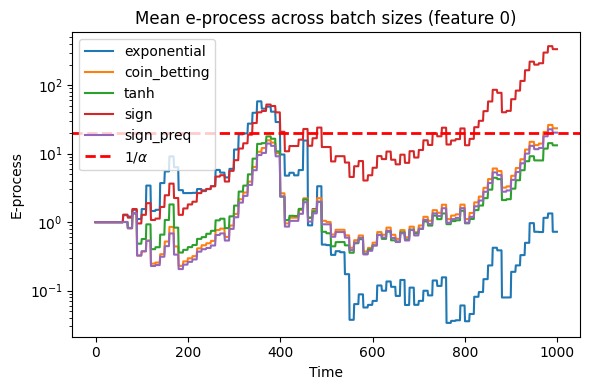

In [20]:
plt.figure(figsize=(6, 4))

batch_list2 = [10]

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j] for b in batch_list2],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

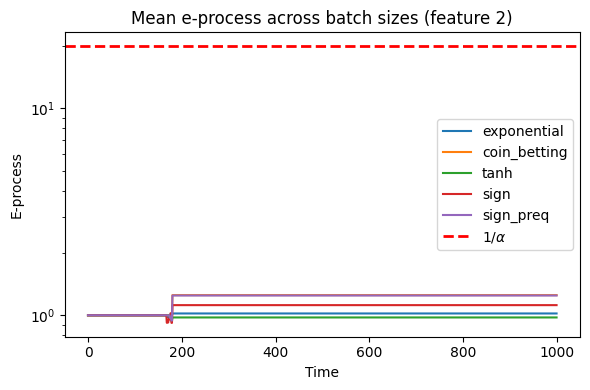

In [22]:
j = 2
plt.figure(figsize=(6, 4))

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

We need more complex models

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor


e_process_gb = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=j_vec,
                 betting_strategies=betting_strategies, model=GradientBoostingRegressor(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )

In [10]:
martingales_gb = e_process_gb.martingales(X, y=Y)

/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), axis=1)
/scratch/areyerol/sequential_ml_testing/src/ExponentialBet.py:47: RuntimeWarning: overflow encountered in exp
  e = np.mean(np.exp(-d), 

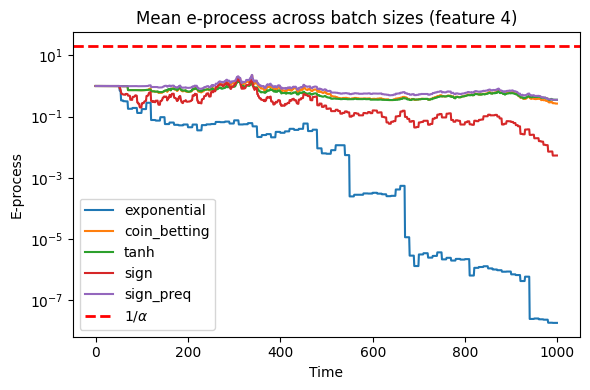

In [24]:
j = 4
plt.figure(figsize=(6, 4))

for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales_gb[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()